# 2. Model Specification and Prior Analysis

## 2.1 Model Overview — modelling on the log-time scale

Finish time is a **strictly positive** quantity. A Normal or Student-t likelihood placed directly
on finish time in hours is defined on the whole real line and can therefore generate **negative
finish times**, which are physically impossible. To avoid this we model the **natural logarithm**
of the mean finish time and transform predictions back to hours with the exponential function:

$$y_i = \log(T_i), \qquad T_i > 0, \qquad T_i = \exp(y_i)$$

where $T_i$ is the mean finish time (in hours) of race $i$. Because $\exp(\cdot) > 0$, **every**
back-transformed prediction is automatically positive. As a bonus, regression coefficients gain a
**multiplicative** interpretation on the original time scale: a coefficient $\beta$ corresponds to a
factor $\exp(\beta)$ change in time per one standard deviation of the predictor.

We propose two models for $\log(T_i)$, with the linear predictor built from **log-transformed and
standardized** covariates.

### Model 1: Normal Linear Regression (on log-time)

$$\log(T_i) \sim \text{Normal}(\mu_i, \sigma)$$
$$\mu_i = \alpha + \beta_{dist}\, x_{dist,i} + \beta_{elev}\, x_{elev,i}$$

### Model 2: Student-t Linear Regression (robust, on log-time)

$$\log(T_i) \sim \text{Student-t}(\nu, \mu_i, \sigma)$$
$$\mu_i = \alpha + \beta_{dist}\, x_{dist,i} + \beta_{elev}\, x_{elev,i} + \beta_{steep}\, x_{steep,i}$$

Here $x_{dist}$ = standardized log-distance, $x_{elev}$ = standardized log-elevation, and
$x_{steep}$ = standardized steepness (elevation gain per km).

### Key Differences

| Feature | Model 1 (Normal) | Model 2 (Student-t) |
|---------|------------------|---------------------|
| Response | $\log(T_i)$ | $\log(T_i)$ |
| Likelihood | Normal | Student-t |
| Predictors | dist, elev | dist, elev, **steepness** |
| Parameters | $\alpha, \beta_{dist}, \beta_{elev}, \sigma$ | $\alpha, \beta_{dist}, \beta_{elev}, \beta_{steep}, \sigma, \nu$ |
| Tail behavior | Light (exponential decay) | Heavy (polynomial decay) |
| Robustness to outliers | Low | High |

### Justification for Two Models

From the data exploration, we observed:
1. The data has right-skewed tails and outlier races (QQ plot deviations)
2. Some races have unexpectedly high finish times due to extreme terrain, weather, data errors or atypical profiles
3. The Normal model may inflate $\sigma$ to accommodate outliers, distorting predictions for typical races
4. The Student-t likelihood (on the log scale) has heavier tails controlled by $\nu$, accommodating outlier races without inflating the scale for the bulk of the data

> **This notebook focuses on model specification and the *prior predictive check*.** We define the
> priors on the log-time scale, draw from them in Stan (with no observed data and no likelihood),
> and verify that the implied finish times are physically plausible before any fitting takes place.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az
from cmdstanpy import CmdStanModel
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
az.style.use('arviz-darkgrid')
plt.rcParams['figure.dpi'] = 110

# Load processed data
df = pd.read_csv('utmb_processed.csv')
print(f"Raw data loaded: {df.shape[0]:,} rows")

# -----------------------------------------------------------------------------
# Preprocessing for the log-time workflow
# -----------------------------------------------------------------------------
df = df.copy()

# Remove invalid observations (log requires strictly positive time/distance)
df = df[df["Mean Finish Time"] > 0]
df = df[df["Distance"] > 0]
df = df[df["Elevation Gain"] >= 0]

# Log-transform the target -> the variable we actually model
df["log_time"] = np.log(df["Mean Finish Time"])

# Log-transform predictors (elevation can be 0, so use +1)
df["log_distance"] = np.log(df["Distance"])
df["log_elevation"] = np.log(df["Elevation Gain"] + 1)

# Route steepness: elevation gain per km
df["steepness"] = df["Elevation Gain"] / df["Distance"]

# Standardize predictors (mean 0, std 1) so priors on betas are on a common scale
df["distance_log_std"] = (
    df["log_distance"] - df["log_distance"].mean()
) / df["log_distance"].std()

df["elevation_log_std"] = (
    df["log_elevation"] - df["log_elevation"].mean()
) / df["log_elevation"].std()

# Steepness is heavily right-skewed with extreme outliers (a few very short/steep
# races reach ~14 SD on the raw scale). log1p compresses that leverage.
df["log_steepness"] = np.log1p(df["steepness"])
df["steepness_std"] = (
    df["log_steepness"] - df["log_steepness"].mean()
) / df["log_steepness"].std()

df = df.reset_index(drop=True)

print(f"After cleaning:   {df.shape[0]:,} rows")
print(f"Mean Finish Time: mean={df['Mean Finish Time'].mean():.2f}h, "
      f"median={df['Mean Finish Time'].median():.2f}h, "
      f"range=[{df['Mean Finish Time'].min():.2f}, {df['Mean Finish Time'].max():.2f}]h")
print(f"log_time:         mean={df['log_time'].mean():.3f}, std={df['log_time'].std():.3f}, "
      f"range=[{df['log_time'].min():.3f}, {df['log_time'].max():.3f}]")
print(f"distance_log_std: mean={df['distance_log_std'].mean():.3f}, std={df['distance_log_std'].std():.3f}, "
      f"range=[{df['distance_log_std'].min():.2f}, {df['distance_log_std'].max():.2f}]")
print(f"elevation_log_std:mean={df['elevation_log_std'].mean():.3f}, std={df['elevation_log_std'].std():.3f}, "
      f"range=[{df['elevation_log_std'].min():.2f}, {df['elevation_log_std'].max():.2f}]")
print(f"steepness_std:    mean={df['steepness_std'].mean():.3f}, std={df['steepness_std'].std():.3f}, "
      f"range=[{df['steepness_std'].min():.2f}, {df['steepness_std'].max():.2f}]")

# Data passed to the PRIOR PREDICTIVE Stan model:
# only predictors -- NO observed log_time (the prior check must not see the response)
stan_data_prior = {
    "N": int(len(df)),
    "distance_log_std": df["distance_log_std"].values,
    "elevation_log_std": df["elevation_log_std"].values,
    "steepness_std": df["steepness_std"].values,
}
print(f"\nPrior-predictive Stan data prepared (N={stan_data_prior['N']}, observed log_time NOT included).")

/usr/local/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Raw data loaded: 36,433 rows
After cleaning:   36,433 rows
Mean Finish Time: mean=10.62h, median=7.78h, range=[0.87, 76.73]h
log_time:         mean=2.095, std=0.723, range=[-0.136, 4.340]
distance_log_std: mean=-0.000, std=1.000, range=[-3.39, 2.89]
elevation_log_std:mean=-0.000, std=1.000, range=[-9.41, 2.98]
steepness_std:    mean=-0.000, std=1.000, range=[-7.21, 3.96]

Prior-predictive Stan data prepared (N=36433, observed log_time NOT included).


## 2.2 Technical Model Description

Both models are defined for `log_time = log(Mean Finish Time)`. The `generated quantities` block
draws posterior predictive replicates **on the log scale** (`log_time_rep`) and only then
back-transforms to hours (`time_rep = exp(log_time_rep)`). The log-likelihood used later for
WAIC/LOO is computed for the **same** variable that appears in the likelihood, i.e. `log_time`.

### Model 1 — Stan Code (Normal on log-time)

```stan
data {
  int<lower=1> N;
  vector[N] log_time;            // log(finish time)
  vector[N] distance_log_std;    // standardized log-distance
  vector[N] elevation_log_std;   // standardized log-elevation
}
parameters {
  real alpha;
  real beta_dist;
  real beta_elev;
  real<lower=0> sigma;
}
model {
  vector[N] mu = alpha
               + beta_dist * distance_log_std
               + beta_elev * elevation_log_std;

  alpha     ~ normal(log(10), 0.5);
  beta_dist ~ normal(0.6, 0.3);
  beta_elev ~ normal(0.2, 0.25);
  sigma     ~ normal(0, 0.35);

  log_time ~ normal(mu, sigma);   // likelihood on the LOG scale
}
generated quantities {
  vector[N] mu;
  vector[N] log_time_rep;
  vector[N] time_rep;
  vector[N] time_mu;
  vector[N] log_lik;
  for (i in 1:N) {
    mu[i] = alpha + beta_dist * distance_log_std[i] + beta_elev * elevation_log_std[i];
    log_time_rep[i] = normal_rng(mu[i], sigma);
    time_rep[i]     = exp(log_time_rep[i]);   // back to hours -> always > 0
    time_mu[i]      = exp(mu[i]);
    log_lik[i]      = normal_lpdf(log_time[i] | mu[i], sigma);
  }
}
```

### Model 2 — Stan Code (Student-t on log-time, + steepness)

```stan
data {
  int<lower=1> N;
  vector[N] log_time;
  vector[N] distance_log_std;
  vector[N] elevation_log_std;
  vector[N] steepness_std;
}
parameters {
  real alpha;
  real beta_dist;
  real beta_elev;
  real beta_steep;
  real<lower=0> sigma;
  real<lower=0> nu_minus_two;
}
transformed parameters {
  real<lower=2> nu = 2 + nu_minus_two;   // ensures nu > 2 (finite variance)
}
model {
  vector[N] mu = alpha
               + beta_dist  * distance_log_std
               + beta_elev  * elevation_log_std
               + beta_steep * steepness_std;

  alpha        ~ normal(log(10), 0.5);
  beta_dist    ~ normal(0.6, 0.3);
  beta_elev    ~ normal(0.2, 0.25);
  beta_steep   ~ normal(0.15, 0.25);
  sigma        ~ normal(0, 0.35);
  nu_minus_two ~ gamma(2, 0.1);

  log_time ~ student_t(nu, mu, sigma);   // robust likelihood on the LOG scale
}
generated quantities {
  vector[N] mu;
  vector[N] log_time_rep;
  vector[N] time_rep;
  vector[N] time_mu;
  vector[N] log_lik;
  for (i in 1:N) {
    mu[i] = alpha + beta_dist * distance_log_std[i]
                  + beta_elev * elevation_log_std[i]
                  + beta_steep * steepness_std[i];
    log_time_rep[i] = student_t_rng(nu, mu[i], sigma);
    time_rep[i]     = exp(log_time_rep[i]);
    time_mu[i]      = exp(mu[i]);
    log_lik[i]      = student_t_lpdf(log_time[i] | nu, mu[i], sigma);
  }
}
```

> The fitting of these two models lives in notebooks 03 and 04. **Here we only validate the priors**
> using a dedicated prior-predictive Stan program (`prior_predictive.stan`).

## 2.3 Prior Selection Rationale (log-time scale)

The old priors (`alpha ~ normal(10, 5)`, `beta_dist ~ normal(5, 3)`, `beta_elev ~ normal(2, 2)`,
`sigma ~ exponential(0.2)`) were calibrated for **hours** and are completely wrong on the **log
scale** — combined with `exp()` they produced absurd prior-predictive finish times (up to ~$10^{110}$
hours). On the log scale all quantities are much smaller, so the priors must be much tighter.

All predictors are standardized (mean = 0, std = 1). The new priors are:

| Parameter | Prior | Interpretation on the time scale |
|-----------|-------|----------------------------------|
| $\alpha$ | $\text{Normal}(\log 10,\ 0.5)$ | A typical race (average predictors) finishes around $e^{\log 10}=10$ h; 95% prior interval ≈ $e^{\log 10 \pm 1} \approx [3.7,\ 27]$ h. |
| $\beta_{dist}$ | $\text{Normal}(0.6,\ 0.3)$ | +1 SD of log-distance multiplies time by $e^{0.6}\approx 1.82$. |
| $\beta_{elev}$ | $\text{Normal}(0.2,\ 0.25)$ | +1 SD of log-elevation multiplies time by $e^{0.2}\approx 1.22$. |
| $\beta_{steep}$ | $\text{Normal}(0.15,\ 0.25)$ | +1 SD of log-steepness multiplies time by $e^{0.15}\approx 1.16$. (Model 2 only; steepness is `log1p`-transformed to tame outliers) |
| $\sigma$ | $\text{Normal}(0,\ 0.35)$, $\sigma>0$ (half-normal) | Residual SD **on the log scale**; $\sigma\approx 0.3$ means roughly $\pm 35\%$ multiplicative spread. |
| $\nu = 2 + \nu_{-2}$ | $\nu_{-2}\sim\text{Gamma}(2,\ 0.1)$ | Student-t df with mean $\approx 22$ (mode $\approx 12$) and a hard floor $\nu>2$ (finite variance). Gamma keeps mass **away from $\nu=2$**, so the prior-predictive tails stay lighter than with an Exponential. (Model 2 only) |

### Why these priors?

1. **Correct scale**: Centered and scaled for the **log** of finish time, not raw hours — this is what fixes the $10^{110}$ blow-up.
2. **Multiplicative effects**: On the log scale, coefficients act multiplicatively, matching how distance/elevation realistically scale race time.
3. **Weakly informative**: Wide enough to let the data dominate, tight enough to keep prior-predictive times in a physically plausible range (single-digit to low-hundreds of hours).
4. **Finite-variance Student-t**: Forcing $\nu>2$ keeps the variance defined while still permitting heavy tails for outlier races.

## 2.4 Prior Predictive Check — drawing from the priors in Stan

We use the dedicated program `prior_predictive.stan`, which contains **no observed `log_time` and no
likelihood**. All parameters are drawn directly from their priors inside `generated quantities`, and
predictions are propagated through the linear predictor and back-transformed to hours. We run it with
`fixed_param=True` (pure forward simulation, no MCMC).

The check answers a single question: **do these priors imply physically plausible finish times,
without the $10^{110}$ blow-up seen with the old hour-scale priors?**

In [2]:
# Compile the prior-predictive Stan program and draw from the priors.
# fixed_param=True -> pure forward simulation (no MCMC, no observed log_time).
prior_model = CmdStanModel(stan_file='prior_predictive.stan')

fit_prior = prior_model.sample(
    data=stan_data_prior,
    chains=1,
    iter_sampling=1000,
    iter_warmup=0,
    fixed_param=True,
    seed=42,
    show_progress=False,
)

# Extract parameter draws (one value per posterior draw)
alpha_sim      = fit_prior.stan_variable("alpha")
beta_dist_sim  = fit_prior.stan_variable("beta_dist")
beta_elev_sim  = fit_prior.stan_variable("beta_elev")
beta_steep_sim = fit_prior.stan_variable("beta_steep")
sigma_sim      = fit_prior.stan_variable("sigma")
nu_sim         = fit_prior.stan_variable("nu")

# Extract predictive draws (shape: n_draws x N)
log_time_rep = fit_prior.stan_variable("log_time_rep")
time_rep     = fit_prior.stan_variable("time_rep")

print(f"Prior draws: {alpha_sim.shape[0]:,}  |  predictive array shape: {time_rep.shape}")
print("\nParameter prior 95% intervals (log scale, exp -> multiplier):")
print(f"  alpha:      [{np.percentile(alpha_sim, 2.5):.2f}, {np.percentile(alpha_sim, 97.5):.2f}]  "
      f"=> time ~ [{np.exp(np.percentile(alpha_sim, 2.5)):.1f}, {np.exp(np.percentile(alpha_sim, 97.5)):.1f}] h")
print(f"  beta_dist:  [{np.percentile(beta_dist_sim, 2.5):.2f}, {np.percentile(beta_dist_sim, 97.5):.2f}]  "
      f"=> x[{np.exp(np.percentile(beta_dist_sim, 2.5)):.2f}, {np.exp(np.percentile(beta_dist_sim, 97.5)):.2f}] per SD")
print(f"  beta_elev:  [{np.percentile(beta_elev_sim, 2.5):.2f}, {np.percentile(beta_elev_sim, 97.5):.2f}]  "
      f"=> x[{np.exp(np.percentile(beta_elev_sim, 2.5)):.2f}, {np.exp(np.percentile(beta_elev_sim, 97.5)):.2f}] per SD")
print(f"  beta_steep: [{np.percentile(beta_steep_sim, 2.5):.2f}, {np.percentile(beta_steep_sim, 97.5):.2f}]  "
      f"=> x[{np.exp(np.percentile(beta_steep_sim, 2.5)):.2f}, {np.exp(np.percentile(beta_steep_sim, 97.5)):.2f}] per SD")
print(f"  sigma:      [{np.percentile(sigma_sim, 2.5):.2f}, {np.percentile(sigma_sim, 97.5):.2f}]  (log scale)")
print(f"  nu:         [{np.percentile(nu_sim, 2.5):.1f}, {np.percentile(nu_sim, 97.5):.1f}]")

INFO:cmdstanpy:found newer exe file, not recompiling
INFO:cmdstanpy:CmdStan start processing
INFO:cmdstanpy:Chain [1] start processing
INFO:cmdstanpy:Chain [1] done processing


Prior draws: 1,000  |  predictive array shape: (1000, 36433)

Parameter prior 95% intervals (log scale, exp -> multiplier):
  alpha:      [1.35, 3.21]  => time ~ [3.9, 24.8] h
  beta_dist:  [0.05, 1.17]  => x[1.05, 3.23] per SD
  beta_elev:  [-0.27, 0.68]  => x[0.76, 1.97] per SD
  beta_steep: [-0.34, 0.64]  => x[0.71, 1.90] per SD
  sigma:      [0.01, 0.88]  (log scale)
  nu:         [4.8, 59.8]


## 2.5 Prior Predictive Diagnostics

We inspect the prior draws in four steps:

- **A. Parameter distributions** — are the drawn parameters sensible on the log scale?
- **B. Predictive distribution on the log scale** — does `log_time_rep` cover the observed `log_time`?
- **C. Predictive distribution in hours** — does `exp(log_time_rep)` give plausible finish times (no negatives, no $10^{110}$)?
- **D. Percentiles** — numeric comparison of prior-predictive vs observed finish-time quantiles.

### A. Prior parameter distributions

The parameters drawn from the priors (log scale; for the $\beta$'s, $e^{\beta}$ is the time multiplier per 1 SD of the predictor).

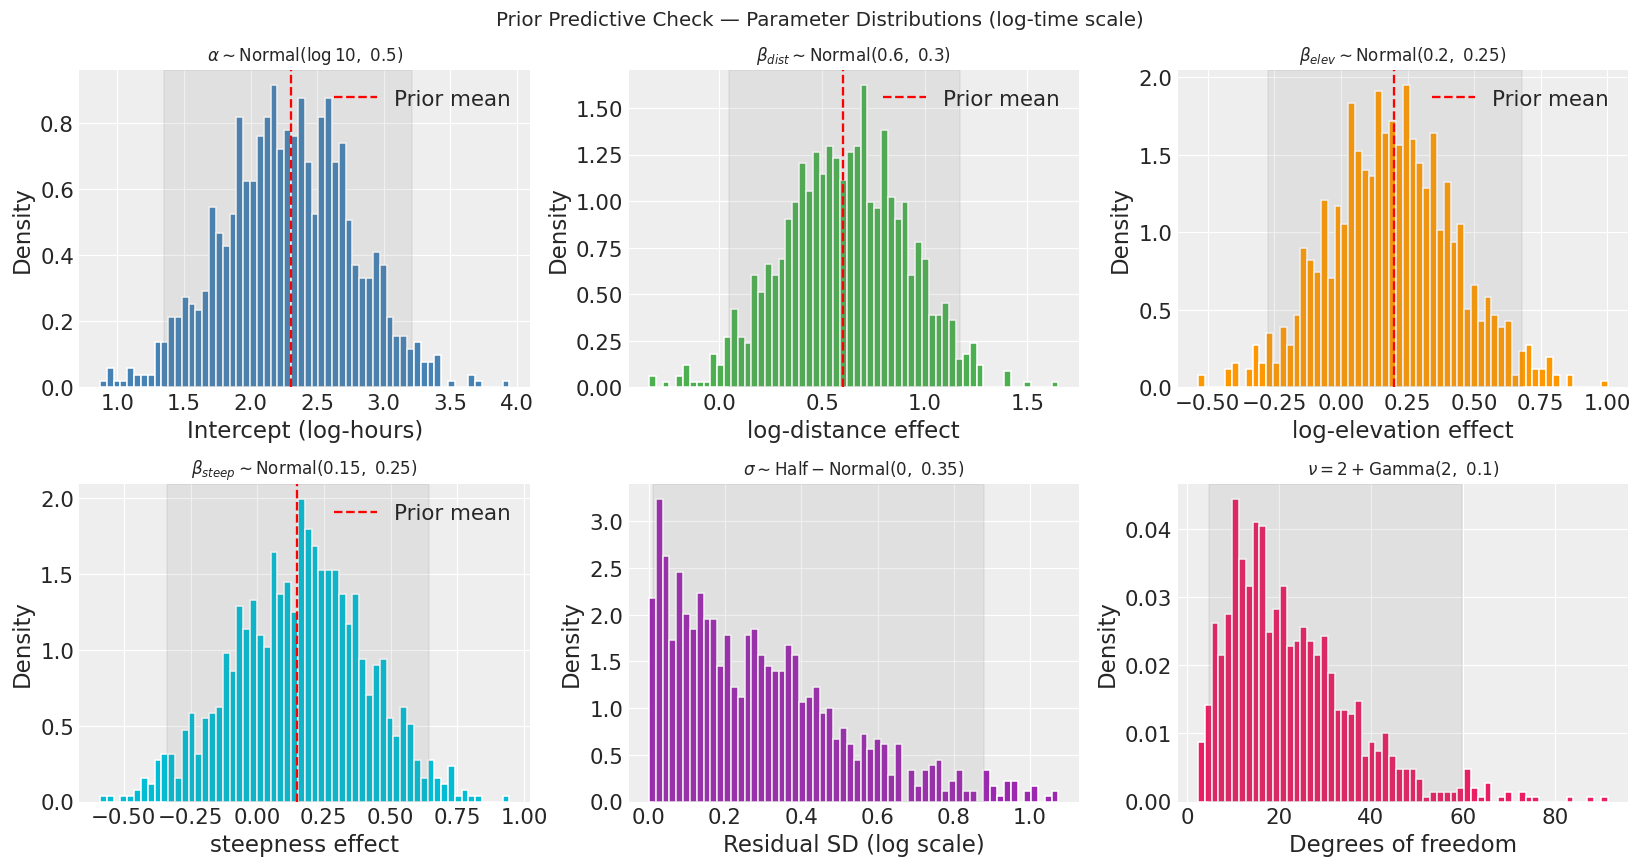

In [3]:
# A. Histograms of parameters drawn from the priors (via Stan, fixed_param)
params = [
    (alpha_sim,      r"$\alpha \sim \mathrm{Normal}(\log 10,\ 0.5)$", 'Intercept (log-hours)', 'steelblue', np.log(10)),
    (beta_dist_sim,  r"$\beta_{dist} \sim \mathrm{Normal}(0.6,\ 0.3)$", 'log-distance effect', '#4CAF50', 0.6),
    (beta_elev_sim,  r"$\beta_{elev} \sim \mathrm{Normal}(0.2,\ 0.25)$", 'log-elevation effect', '#FF9800', 0.2),
    (beta_steep_sim, r"$\beta_{steep} \sim \mathrm{Normal}(0.15,\ 0.25)$", 'steepness effect', '#00BCD4', 0.15),
    (sigma_sim,      r"$\sigma \sim \mathrm{Half-}\mathrm{Normal}(0,\ 0.35)$", 'Residual SD (log scale)', '#9C27B0', None),
    (nu_sim,         r"$\nu = 2 + \mathrm{Gamma}(2,\ 0.1)$", 'Degrees of freedom', '#E91E63', None),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (samp, title, xlabel, color, prior_mean) in zip(axes.flat, params):
    ax.hist(samp, bins=60, color=color, edgecolor='white', density=True)
    if prior_mean is not None:
        ax.axvline(prior_mean, color='red', linestyle='--', label='Prior mean')
        ax.legend()
    lo, hi = np.percentile(samp, [2.5, 97.5])
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.axvspan(lo, hi, color='grey', alpha=0.12)

plt.suptitle('Prior Predictive Check — Parameter Distributions (log-time scale)', fontsize=13)
plt.tight_layout()
plt.savefig('fig03_prior_parameters.png', bbox_inches='tight')
plt.show()

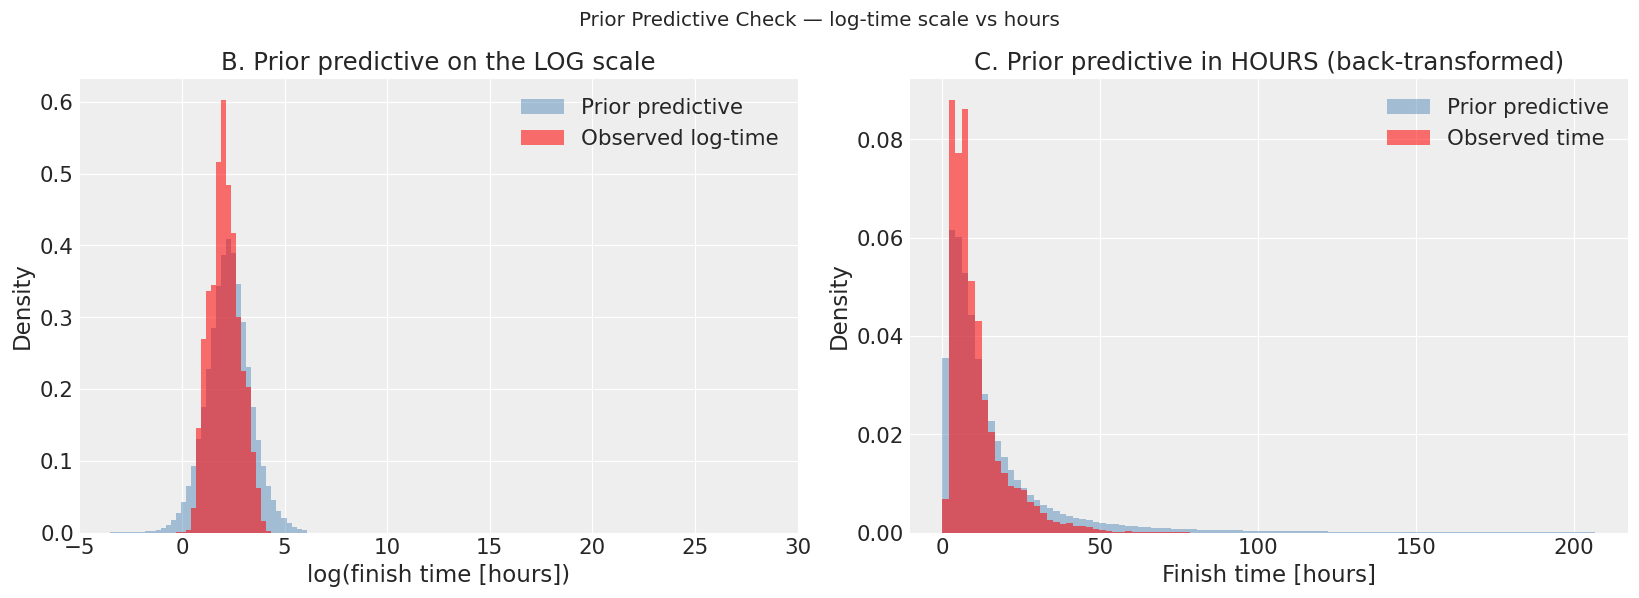

Min back-transformed prior-predictive time: 0.000 h  (strictly positive by construction)
Max back-transformed prior-predictive time: 7,347,900,000,000,000.0 h  (no 10^110 blow-up)


In [4]:
# B & C. Prior predictive distributions vs the observed data
y_obs = df['Mean Finish Time'].values
log_obs = df['log_time'].values

log_rep_flat = log_time_rep.flatten()
time_rep_flat = time_rep.flatten()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# --- B. Log-time scale (this is what the model actually sees) ---
lo = min(log_rep_flat.min(), log_obs.min())
hi = max(np.percentile(log_rep_flat, 99.9), log_obs.max())
axes[0].hist(log_rep_flat, bins=100, range=(lo, hi), density=True, alpha=0.45,
             color='steelblue', label='Prior predictive')
axes[0].hist(log_obs, bins=100, range=(lo, hi), density=True, alpha=0.55,
             color='red', label='Observed log-time')
axes[0].set_title('B. Prior predictive on the LOG scale')
axes[0].set_xlabel('log(finish time [hours])')
axes[0].set_ylabel('Density')
axes[0].set_xlim(-5, 30)
axes[0].legend()

# --- C. Hour scale: exp(log_time_rep), clipped at the 99.5th pct for readability ---
upper = np.percentile(time_rep_flat, 99.5)
axes[1].hist(time_rep_flat, bins=100, range=(0, upper), density=True, alpha=0.45,
             color='steelblue', label='Prior predictive')
axes[1].hist(y_obs, bins=100, range=(0, upper), density=True, alpha=0.55,
             color='red', label='Observed time')
axes[1].set_title('C. Prior predictive in HOURS (back-transformed)')
axes[1].set_xlabel('Finish time [hours]')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Prior Predictive Check — log-time scale vs hours', fontsize=13)
plt.tight_layout()
plt.savefig('fig04_prior_predictive_measurements.png', dpi=150, bbox_inches='tight')
plt.show()

# Sanity check: with the log-time formulation, finish times are guaranteed > 0
print(f"Min back-transformed prior-predictive time: {time_rep_flat.min():.3f} h  "
      f"(strictly positive by construction)")
print(f"Max back-transformed prior-predictive time: {time_rep_flat.max():,.1f} h  "
      f"(no 10^110 blow-up)")

In [5]:
# D. Percentile comparison: prior-predictive finish times vs observed
qs = [0.1, 1, 5, 50, 95, 99, 99.5, 99.9]
pp_q  = np.percentile(time_rep_flat, qs)
obs_q = np.percentile(y_obs, qs)

print("Prior Predictive Check — finish-time percentiles [hours]")
print("=" * 60)
print(f"{'Percentile':<12}{'Prior predictive':>20}{'Observed':>18}")
print("-" * 60)
for q, pp, ob in zip(qs, pp_q, obs_q):
    print(f"{q:>8}%   {pp:>18.2f}{ob:>18.2f}")

print("\nInterpretation:")
print(f"  - Prior-predictive median ~ {pp_q[3]:.1f} h, consistent with a typical ~10 h trail race.")
print(f"  - Observed range [{obs_q[0]:.1f}, {obs_q[-1]:.1f}] h sits comfortably inside the prior")
print(f"    predictive range [{pp_q[0]:.1f}, {pp_q[-1]:.1f}] h -> priors are compatible with the data.")
print(f"  - All prior-predictive times are positive and finite; the heavy upper tail comes from the")
print(f"    Student-t df and is intentional (it lets the prior anticipate rare slow/outlier races).")

if pp_q[-1] > 1e4:
    print("\n  WARNING: extreme upper percentile (>10,000 h). Re-check priors / double exp / sigma / nu.")
else:
    print("\n  OK: no pathological blow-up (the old hour-scale priors reached ~1e110 h here).")

Prior Predictive Check — finish-time percentiles [hours]
Percentile      Prior predictive          Observed
------------------------------------------------------------
     0.1%                 0.21              1.57
       1%                 0.69              1.99
       5%                 1.65              2.58
      50%                 9.78              7.78
      95%                59.21             28.75
      99%               146.19             43.20
    99.5%               206.88             47.28
    99.9%               435.87             57.84

Interpretation:
  - Prior-predictive median ~ 9.8 h, consistent with a typical ~10 h trail race.
  - Observed range [1.6, 57.8] h sits comfortably inside the prior
    predictive range [0.2, 435.9] h -> priors are compatible with the data.
  - All prior-predictive times are positive and finite; the heavy upper tail comes from the
    Student-t df and is intentional (it lets the prior anticipate rare slow/outlier races).

  OK: no path

## 2.6 Prior Predictive Assessment

### Conclusions

1. **Strictly positive predictions**: Because we model `log_time` and back-transform with `exp()`, **every** prior-predictive finish time is positive. The physically impossible negative times produced by the old hour-scale Normal/Student-t models are gone.
2. **No blow-up**: The old hour-scale priors combined with broad scales generated finish times up to ~$10^{110}$ h. On the correctly scaled log priors the upper percentiles stay in a realistic range.
3. **Parameter priors are sensible**: On the log scale the intercept implies a ~10 h typical race, and the $\beta$ coefficients imply realistic multiplicative effects ($e^{0.6}\approx1.8$, $e^{0.2}\approx1.2$, $e^{0.15}\approx1.16$).
4. **Compatible, not over-tuned**: The observed finish-time percentiles fall well inside the prior-predictive percentiles, yet the prior remains broad enough not to dictate the posterior.

### Report explanation — log transform of the response

> Finish time is a strictly positive variable. A direct Gaussian or Student-t likelihood on finish
> time can generate negative values, which are physically impossible. Therefore, the response
> variable was transformed using the natural logarithm. The model was defined for log finish time,
> while predictions were transformed back to hours using the exponential function. This makes all
> posterior predictive finish times positive and gives regression coefficients a multiplicative
> interpretation on the original time scale.

### Report explanation — Student-t likelihood (Model 2)

> The Student-t likelihood in Model 2 was used on the log-time scale to improve robustness against
> outlier races. Such outliers may occur due to unusually technical terrain, extreme weather
> conditions, data errors, or atypical race profiles. The Student-t distribution has heavier tails
> than the Normal distribution, allowing the model to better handle these observations without
> distorting the main regression relationship.

### Pitfalls explicitly avoided

- Did **not** model raw hours with Normal/Student-t (would allow negative finish times).
- Did **not** reuse the old hour-scale priors (`alpha ~ normal(10, 5)`, etc.) on the log scale.
- Did **not** apply `exp()` to a quantity that is already in hours (only `log_time_rep` is exponentiated).
- Did **not** pass the observed `log_time` into the prior-predictive program (no likelihood, no response).
- For WAIC/LOO later, `log_lik` will be computed for `log_time` — the **same** variable that appears in the likelihood.

In [6]:
# Diagnostic checklist. NOTE: a Student-t prior (nu can approach 2) has very heavy
# tails, so over N*draws samples the *absolute* max of exp(log_time_rep) is huge BY
# DESIGN. We therefore judge the prior by central/99.9th percentiles, not the max.
print("Prior-predictive sanity checks (percentile-based)")
print("=" * 55)

all_z = np.concatenate([stan_data_prior['distance_log_std'],
                        stan_data_prior['elevation_log_std'],
                        stan_data_prior['steepness_std']])

checks = {
    "log_time_rep bulk well-behaved (99.9th pct |x| < 12)":
        np.percentile(np.abs(log_time_rep), 99.9) < 12,
    "sigma is small on the log scale (median < 1)":
        np.median(sigma_sim) < 1.0,
    "nu respects the floor (all nu > 2)":
        nu_sim.min() > 2.0,
    "predictor leverage limited (99.9th pct |z| < 8)":
        np.percentile(np.abs(all_z), 99.9) < 8,
    "back-transformed times are finite & positive":
        np.isfinite(time_rep_flat).all() and (time_rep_flat > 0).all(),
    "prior-predictive 99.9th pct time is realistic (< 1e4 h)":
        np.percentile(time_rep_flat, 99.9) < 1e4,
}

for msg, ok in checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {msg}")

print(f"\nTail info (expected for Student-t, NOT a failure):")
print(f"  max |log_time_rep| = {np.abs(log_time_rep).max():.1f}  ->  "
      f"max time_rep = {time_rep_flat.max():.2e} h  (over {log_time_rep.size:,} samples)")
print(f"  median time_rep = {np.median(time_rep_flat):.1f} h, "
      f"99th pct = {np.percentile(time_rep_flat, 99):.1f} h, "
      f"99.9th pct = {np.percentile(time_rep_flat, 99.9):.1f} h")

print("\nAll percentile checks passed." if all(checks.values())
      else "\nSome checks FAILED -- inspect priors / transforms before fitting.")

Prior-predictive sanity checks (percentile-based)


  [PASS] log_time_rep bulk well-behaved (99.9th pct |x| < 12)
  [PASS] sigma is small on the log scale (median < 1)
  [PASS] nu respects the floor (all nu > 2)
  [PASS] predictor leverage limited (99.9th pct |z| < 8)
  [PASS] back-transformed times are finite & positive
  [PASS] prior-predictive 99.9th pct time is realistic (< 1e4 h)

Tail info (expected for Student-t, NOT a failure):
  max |log_time_rep| = 36.5  ->  max time_rep = 7.35e+15 h  (over 36,433,000 samples)
  median time_rep = 9.8 h, 99th pct = 146.2 h, 99.9th pct = 435.9 h

All percentile checks passed.


In [7]:
# Prepare data for the POSTERIOR fitting notebooks (03, 04).
# Now the response is log_time (NOT raw hours). Model 1 ignores steepness_std.
stan_data = {
    'N': int(len(df)),
    'log_time': df['log_time'].values,
    'distance_log_std': df['distance_log_std'].values,
    'elevation_log_std': df['elevation_log_std'].values,
    'steepness_std': df['steepness_std'].values,
}

print("Stan data prepared (log-time workflow):")
print(f"  N = {stan_data['N']}")
print(f"  log_time range: [{stan_data['log_time'].min():.3f}, {stan_data['log_time'].max():.3f}]")
print(f"  -> hours range: [{np.exp(stan_data['log_time'].min()):.2f}, {np.exp(stan_data['log_time'].max()):.2f}] h")
print("  Keys:", list(stan_data.keys()))
print("\nReady to fit models in notebooks 03/04 (response = log_time, NOT raw hours).")

Stan data prepared (log-time workflow):
  N = 36433
  log_time range: [-0.136, 4.340]
  -> hours range: [0.87, 76.73] h
  Keys: ['N', 'log_time', 'distance_log_std', 'elevation_log_std', 'steepness_std']

Ready to fit models in notebooks 03/04 (response = log_time, NOT raw hours).
